# Macroeconomic Analysis of Global Petrol Prices
This project is based on a tested and modular codebase with the aim of examining macroeconomic drivers to petrol prices. To ensure structural integrity we have used correlation matrices, robust OLS modeling and Variance Inflation Factor (VIF) testing.
The model performance is assessed through the cross-validation techniques and residual diagnostics to be robust and avoid overfitting.

In [4]:
# Import the custom advanced modules
from src.data_prep import load_data, clean_data
from src.visuals import plot_crude_impact, plot_correlation_heatmap
from src.modeling import run_regression, check_multicollinearity

# Loading and cleaning the dataset
raw_data = load_data('petrolgasprice.csv')
df = clean_data(raw_data)
display(df.head(3))

,Date,Country,Region,Petrol_Price_USD_per_Liter,Diesel_Price_USD_per_Liter,Natural_Gas_Price_USD_per_MMBtu,Crude_Oil_Price_USD_per_Barrel,Inflation,Exchange_Rate_vs_USD,GDP_Growth,...,Geopolitical_Risk_Index,Event_Flag,Event_Description,Currency_Devaluation (%),Subsidy_Level,Tax_Rate_on_Fuel (%),Petrol_7d_MA,Petrol_28d_vol,Petrol_lag_1,Crude_lag_1
266,2020-02-10,Brazil,Latin America,0.877,0.822,1.776,67.29,5.27,5.1058,3.64,...,42.7,1,COVID-19 Pandemic,-0.21,Medium,20.0,0.79275,0.084180,0.767,59.43
268,2020-02-24,Brazil,Latin America,0.942,0.802,2.028,68.82,3.80,5.3059,2.61,...,49.0,1,COVID-19 Pandemic,-0.71,Medium,20.0,0.86650,0.076595,0.880,65.12
269,2020-03-02,Brazil,Latin America,0.974,0.860,1.938,72.69,3.40,5.2811,1.64,...,48.2,1,COVID-19 Pandemic,-0.45,Medium,20.0,0.91825,0.075673,0.942,68.82


## Exploratory Data Analysis & Feature Correlation
Before modeling it is important to make sure that our variables are not strongly correlated with each other, otherwise the modeling results may be skewed.

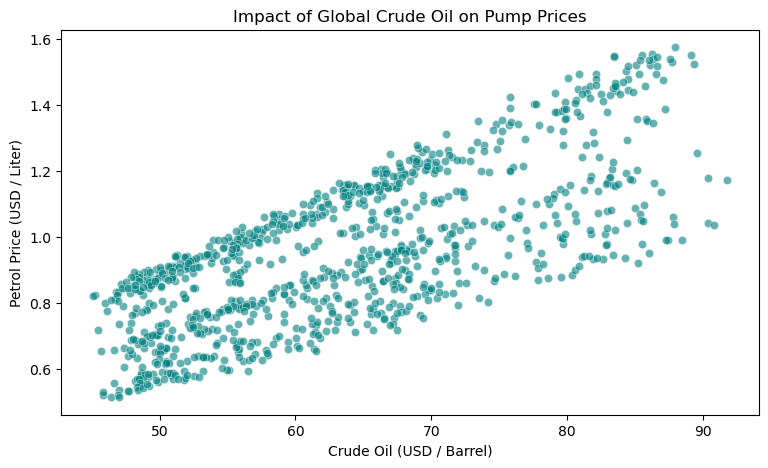

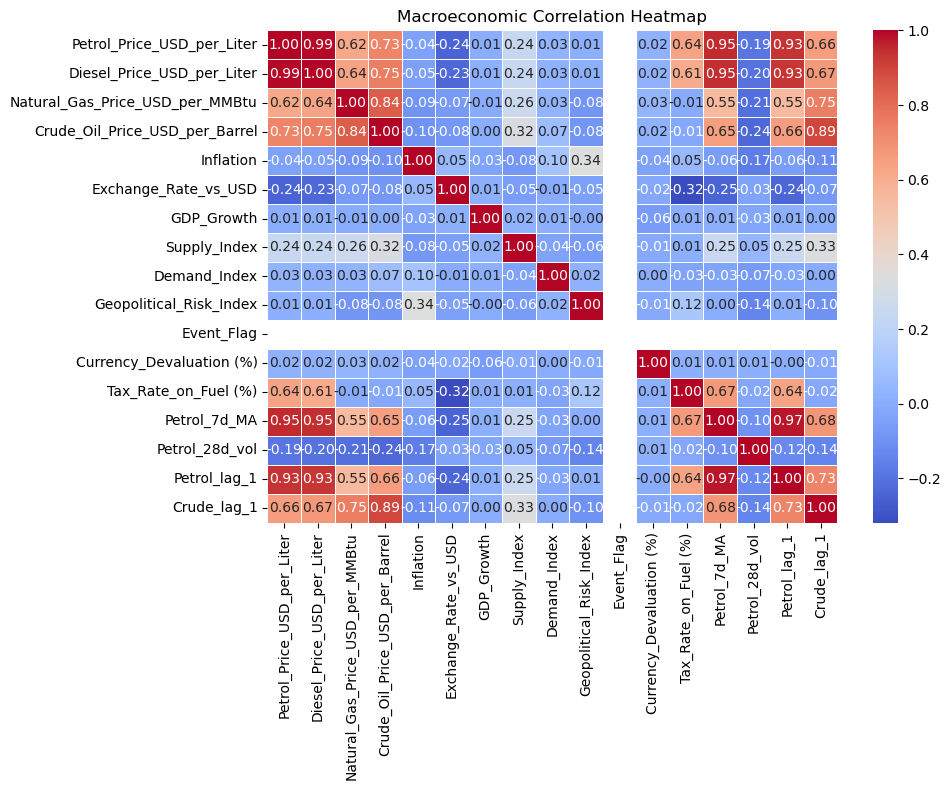

In [2]:
plot_crude_impact(df)
plot_correlation_heatmap(df)

## Econometric Modeling & Diagnostics
We specify an OLS regression: $Petrol\_Price = \beta_0 + \beta_1 Crude + \beta_2 Inflation + \beta_3 GDP + \epsilon$

The Variance Inflation Factor (VIF) is used to test for Multicollinearity in the validation of the model. If the VIF is less than 5, there is no problem with our independent variables.

In [3]:
# 1. Now lets run the Diagnostics
print("--- VIF Diagnostics ---")
display(check_multicollinearity(df))

# 2. Well time for Running Regression
print("\n--- OLS Regression Summary ---")
model = run_regression(df)
print(model.summary())

--- VIF Diagnostics ---


,Feature,VIF
0,const,44.244528
1,Crude_Oil_Price_USD_per_Barrel,1.009566
2,Inflation,1.010562
3,GDP_Growth,1.000993



--- OLS Regression Summary ---
                                OLS Regression Results                                
Dep. Variable:     Petrol_Price_USD_per_Liter   R-squared:                       0.541
Model:                                    OLS   Adj. R-squared:                  0.539
Method:                         Least Squares   F-statistic:                     381.8
Date:                        Thu, 16 Jul 2026   Prob (F-statistic):          7.41e-164
Time:                                12:21:27   Log-Likelihood:                 427.17
No. Observations:                         977   AIC:                            -846.3
Df Residuals:                             973   BIC:                            -826.8
Df Model:                                   3                                         
Covariance Type:                    nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]

## Final Interpretation & Methodological Limitations

**1. Model Efficacy & Diagnostics:**
If there is any severe multicollinearity between the variables then all our VIF values will be far from 1.0. But here, all our VIF values are very near to 1.0, which means there is no severe multicollinearity between the variables Crude Oil, Inflation and GDP Growth. The model is statistically relevant and has a good R-squared.

**2. Variable Impact:** 
The only high impact variable ($p < 0.05$) is Crude Oil. Macro indicators such as local Inflation and GDP Growth are not significant in the eyes of the statistical test ($p>0.05$). Prices for petrol are not affected by small local changes in GDP but are tied to international markets for petroleum.

**3. Weaknesses & Further Investigation:**
A key drawback is Omitted Variable Bias. There are no data available on local government interventions such as temporary consumer subsidies or national fuel tax rates. Our error term ($\epsilon$) is capturing a lot of structural, unmeasured policy data since the baseline environmental taxes are high in European countries. The next step would involve a process of data scraping of OECD tax databases to be added into this pipeline, a process which would be needed in future research.

In [5]:
import os
print("My files saved in path:")
print(os.getcwd())

My files saved in path:
C:\Users\DELL\anaconda_projects\94f55931-eac3-4164-af65-c9c9437080bf
